In [31]:
from youtube_transcript_api import YouTubeTranscriptApi
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START,END
from typing import TypedDict, Literal, List
from langchain_core.documents import Document
import re
import requests
import uuid
import hashlib

In [32]:
load_dotenv()

True

In [33]:
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
db_name = "./chroma_vector_store_yt"


In [34]:
class ChatState(TypedDict):
    query : str
    url : str
    title: str
    is_upload : bool
    documents: List[Document]
    video_id: str

In [35]:
def fetch_youtube_title(url: str) -> str:
    """Fetches the title of a YouTube video using the official OEmbed API."""
    
    oembed_url = f"https://www.youtube.com/oembed?url={url}&format=json"
    
    try:
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(oembed_url, headers=headers, timeout=5)
        
        response.raise_for_status() 
        
        data = response.json()
        return data.get("title", "Unknown Title")
        
    except Exception as e:
        print(f"Error fetching title: {e}")
        return "Unknown Title"

In [36]:
def fetch_youtube_transcript(url: str) -> str:
    """Extracts the video ID from a URL and fetches the full text transcript."""
    
    match = get_video_id_match(url)
    
    if not match:
        raise ValueError("Could not find a valid YouTube Video ID in the provided URL.")
        
    video_id = match.group(1)
    
    try:
        raw_transcript = YouTubeTranscriptApi.get_transcript(video_id)
        
        full_text = " ".join([segment['text'] for segment in raw_transcript])
        
        full_text = full_text.replace('\n', ' ')
        
        return full_text

    except Exception as e:
        print(f"Error fetching transcript: {e}")
        return None

def get_video_id_match(url):
    pattern = r"(?:https?:\/\/)?(?:www\.)?(?:youtube\.com\/(?:watch\?.*v=|embed\/|shorts\/|v\/)|youtu\.be\/)([\w-]{11})"
    match = re.search(pattern, url)
    return match

In [ ]:
def upload_document(state: ChatState):
    url = state["url"]
    transcript = fetch_youtube_transcript(url)
    title = fetch_youtube_title(url)

    match = get_video_id_match(url)
    if not match:
        raise ValueError("Could not find a valid YouTube Video ID in the provided URL.")
    video_id = match.group(1)

    if transcript:
        doc = Document(page_content=transcript, metadata={"source": url})
        
        splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
        chunks = splitter.split_documents([doc])

        ids = []
        for index, chunk in enumerate(chunks):
            unique_string = f"{url}_chunk_{index}"
            
            chunk_id = hashlib.md5(unique_string.encode()).hexdigest()
            ids.append(chunk_id)
            
            # (Optional) Save the chunk number in metadata so the AI knows order
            chunk.metadata["chunk_number"] = index
            chunk.metadata["video_id"] = video_id
            chunk.metadata["title"] = title

        vector_store = Chroma.from_documents(
            documents=chunks,
            embedding=embeddings,
            ids=ids,
            persist_directory=db_name
        )

        return {"documents": chunks, "title": title, "video_id": video_id} # Update the state
    else:
        print(f"Warning: No transcript found for {url}")
        return {"documents": [], "title": title, "video_id": video_id}

In [38]:
def retrive_document(state: ChatState):
    pass

In [39]:
def chat_node(state: ChatState):
    pass

In [40]:
def route(state: ChatState) -> Literal["upload", "retrive"]:
    pass

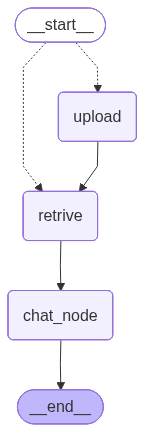

In [41]:
workflow = StateGraph(ChatState)

workflow.add_node("upload", upload_document)
workflow.add_node("retrive", retrive_document)
workflow.add_node("chat_node", chat_node)

workflow.add_conditional_edges(START, route)
workflow.add_edge("upload", "retrive")
workflow.add_edge("retrive", "chat_node")
workflow.add_edge("chat_node", END)

app = workflow.compile()
app